In [1]:
# CELL 1 — Imports & Style Setup
# Loads all libraries and sets a dark professional chart theme
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': '#0A0E1A',
    'axes.facecolor': '#111827',
    'axes.edgecolor': '#1F2937',
    'axes.labelcolor': '#D1D5DB',
    'xtick.color': '#6B7280',
    'ytick.color': '#6B7280',
    'grid.color': '#1F2937',
    'grid.alpha': 0.7,
    'text.color': '#F3F4F6',
    'font.family': 'DejaVu Sans',
    'axes.titlepad': 14,
    'axes.titlesize': 12,
    'axes.titleweight': 'bold',
})
COLORS = ['#38BDF8', '#F472B6', '#34D399', '#FBBF24', '#A78BFA']

print("✅ Libraries loaded. Dark theme configured.")

✅ Libraries loaded. Dark theme configured.


In [2]:
# CELL 2 — Generate Synthetic Climate Dataset
# Creates 65 years x 12 months x 5 cities = 3,900 records.
# Includes real-world effects: warming trend, seasonality, El Niño anomalies.
np.random.seed(42)
years  = np.arange(1960, 2025)
cities = ['Mumbai', 'Delhi', 'Bangalore', 'Chennai', 'Kolkata']
base_temp = {'Mumbai': 27, 'Delhi': 25, 'Bangalore': 22, 'Chennai': 28, 'Kolkata': 26}
base_rain = {'Mumbai': 180, 'Delhi': 60,  'Bangalore': 90, 'Chennai': 100, 'Kolkata': 120}

rows = []
for city in cities:
    for year in years:
        for month in range(1, 13):
            warming   = (year - 1960) * 0.018
            seasonal_t = 8  * np.sin(2*np.pi*(month-4)/12)
            seasonal_r = 60 * np.sin(2*np.pi*(month-6)/12)
            noise_t   = np.random.normal(0, 1.2)
            noise_r   = np.random.normal(0, 20)
            anomaly   = 2.5 if year in [1998, 2010, 2016, 2020] else 0
            temp = round(base_temp[city] + warming + seasonal_t + noise_t + anomaly, 2)
            rain = round(max(0, base_rain[city] + seasonal_r + noise_r), 2)
            rows.append({'year': year, 'month': month, 'city': city,
                         'temperature': temp, 'rainfall_mm': rain,
                         'date': pd.Timestamp(year=year, month=month, day=1)})

df = pd.DataFrame(rows)
df['decade'] = (df['year'] // 10) * 10
df.to_csv('climate_data.csv', index=False)

print(f"✅ Dataset created: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"📅 Period: {df['year'].min()} – {df['year'].max()}  |  Cities: {df['city'].nunique()}")
print(f"❌ Null values: {df.isnull().sum().sum()}")
df.head(8)

✅ Dataset created: 3,900 rows × 7 columns
📅 Period: 1960 – 2024  |  Cities: 5
❌ Null values: 0


,year,month,city,temperature,rainfall_mm,date,decade
0,1960,1,Mumbai,19.60,147.23,1960-01-01,1960
1,1960,2,Mumbai,20.85,158.50,1960-02-01,1960
2,1960,3,Mumbai,22.72,115.32,1960-03-01,1960
3,1960,4,Mumbai,28.90,143.39,1960-04-01,1960
4,1960,5,Mumbai,30.44,160.85,1960-05-01,1960
5,1960,6,Mumbai,33.37,170.69,1960-06-01,1960
6,1960,7,Mumbai,35.29,171.73,1960-07-01,1960
7,1960,8,Mumbai,31.86,220.72,1960-08-01,1960


In [3]:
# CELL 3 — Data Overview & Summary Stats
# Quick check: data types, basic stats per city.
print("="*55)
print("  CLIMATE DATASET — OVERVIEW")
print("="*55)
print(f"\n🔢 Shape     : {df.shape}")
print(f"🏙️  Cities    : {list(df['city'].unique())}")
print(f"📅 Years     : {df['year'].min()} → {df['year'].max()}")
print(f"❄️  Min Temp  : {df['temperature'].min()}°C")
print(f"🔥 Max Temp  : {df['temperature'].max()}°C")
print(f"🌧️  Avg Rain  : {df['rainfall_mm'].mean():.1f} mm/month")
print("\n📊 Temperature Summary by City:")
df.groupby('city')['temperature'].agg(['mean','min','max','std']).round(2)

  CLIMATE DATASET — OVERVIEW

🔢 Shape     : (3900, 7)
🏙️  Cities    : ['Mumbai', 'Delhi', 'Bangalore', 'Chennai', 'Kolkata']
📅 Years     : 1960 → 2024
❄️  Min Temp  : 11.79°C
🔥 Max Temp  : 41.82°C
🌧️  Avg Rain  : 110.1 mm/month

📊 Temperature Summary by City:


,mean,min,max,std
city,,,,
Bangalore,22.71,11.79,34.55,5.85
Chennai,28.72,17.73,41.82,5.92
Delhi,25.69,14.81,37.50,5.83
Kolkata,26.74,16.07,39.37,5.82
Mumbai,27.79,16.36,39.62,5.82


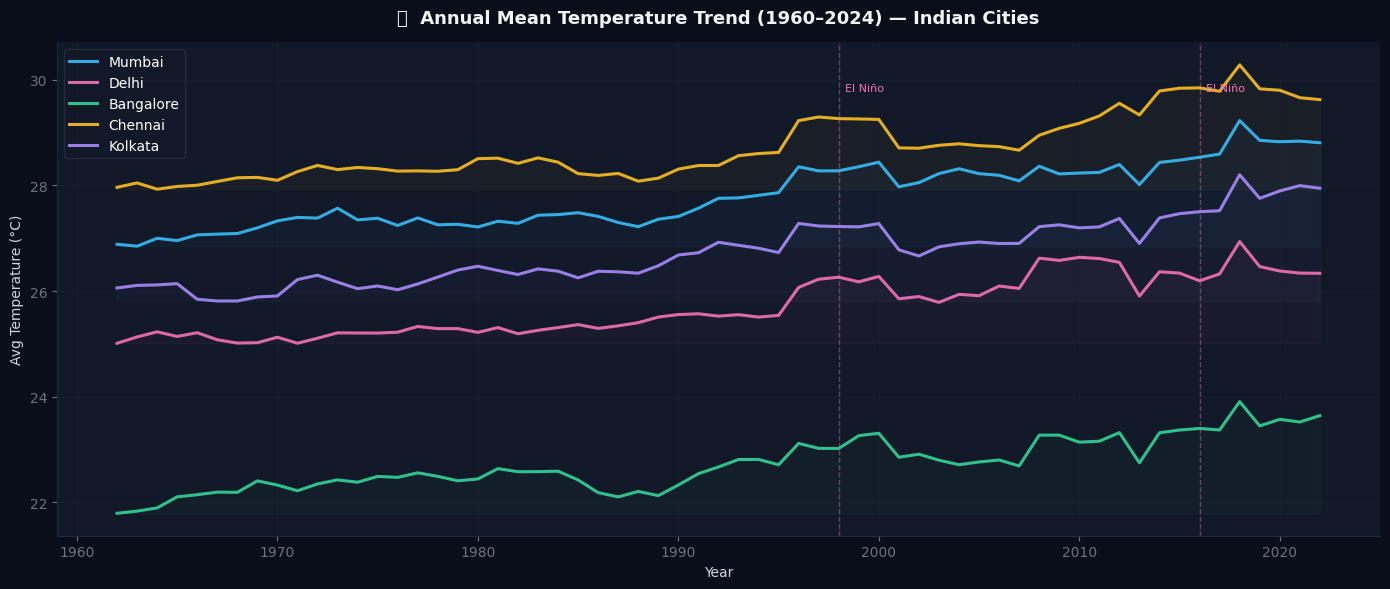

💾 Saved: chart1_temp_trend.png


In [4]:
# CELL 4 — EDA Chart 1: Temperature Trend Over Decades
# Shows long-term warming signal for all 5 Indian cities (1960–2024).
fig, ax = plt.subplots(figsize=(14, 6))
for i, city in enumerate(cities):
    city_df = df[df['city']==city].groupby('year')['temperature'].mean()
    smoothed = city_df.rolling(5, center=True).mean()
    ax.plot(city_df.index, smoothed, color=COLORS[i], linewidth=2.2, label=city, alpha=0.9)
    ax.fill_between(city_df.index, smoothed, smoothed.min(), alpha=0.04, color=COLORS[i])

ax.set_title('🌡️  Annual Mean Temperature Trend (1960–2024) — Indian Cities', color='#F3F4F6', fontsize=13)
ax.set_xlabel('Year'); ax.set_ylabel('Avg Temperature (°C)')
ax.legend(framealpha=0.1, labelcolor='white', loc='upper left')
ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
for yr, label in [(1998, 'El Niño'), (2016, 'El Niño')]:
    ax.axvline(x=yr, color='#F472B6', alpha=0.4, linewidth=1, linestyle='--')
    ax.text(yr+0.3, ax.get_ylim()[1]*0.97, label, color='#F472B6', fontsize=8)

plt.tight_layout()
plt.savefig('chart1_temp_trend.png', dpi=150, bbox_inches='tight', facecolor='#0A0E1A')
plt.show()
print("💾 Saved: chart1_temp_trend.png")

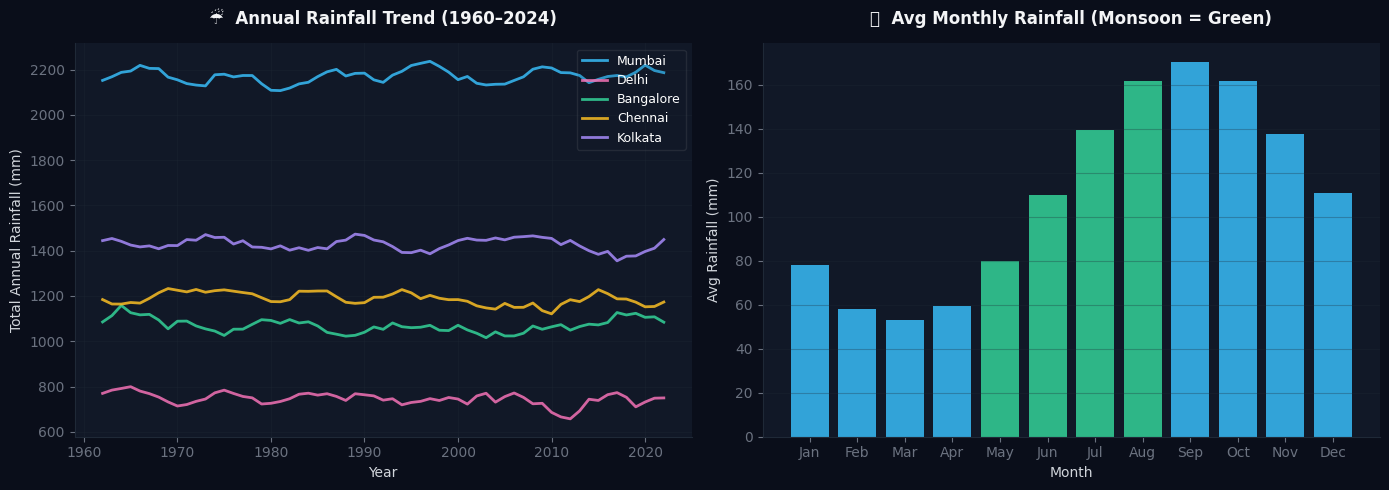

💾 Saved: chart2_rainfall.png


In [5]:
# CELL 5 — EDA Chart 2: Rainfall Trend & Monthly Pattern
# Left: annual rainfall trend per city. Right: avg monthly distribution (monsoon highlighted).
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

rain_annual = df.groupby(['city','year'])['rainfall_mm'].sum().reset_index()
for i, city in enumerate(cities):
    cd = rain_annual[rain_annual['city']==city]
    smoothed = cd['rainfall_mm'].rolling(5, center=True).mean()
    axes[0].plot(cd['year'].values, smoothed.values, color=COLORS[i], label=city, linewidth=2, alpha=0.85)
axes[0].set_title('☔  Annual Rainfall Trend (1960–2024)')
axes[0].set_xlabel('Year'); axes[0].set_ylabel('Total Annual Rainfall (mm)')
axes[0].legend(framealpha=0.1, labelcolor='white', fontsize=9)
axes[0].grid(True, alpha=0.3)
axes[0].spines['top'].set_visible(False); axes[0].spines['right'].set_visible(False)

month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly_rain = df.groupby('month')['rainfall_mm'].mean()
bar_colors = ['#34D399' if m in [5,6,7,8] else '#38BDF8' for m in range(1,13)]
axes[1].bar(month_names, monthly_rain.values, color=bar_colors, alpha=0.85, edgecolor='none')
axes[1].set_title('🌧️  Avg Monthly Rainfall (Monsoon = Green)')
axes[1].set_xlabel('Month'); axes[1].set_ylabel('Avg Rainfall (mm)')
axes[1].grid(True, axis='y', alpha=0.3)
axes[1].spines['top'].set_visible(False); axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('chart2_rainfall.png', dpi=150, bbox_inches='tight', facecolor='#0A0E1A')
plt.show()
print("💾 Saved: chart2_rainfall.png")

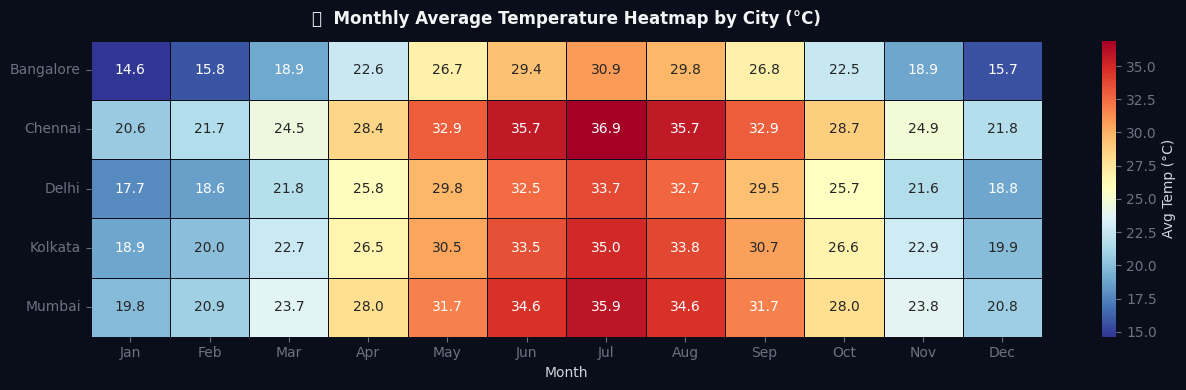

💾 Saved: chart3_heatmap.png


In [6]:
# CELL 6 — EDA Chart 3: Monthly Temperature Heatmap
# Shows seasonal temperature patterns for each city across all 12 months.
pivot = df.groupby(['city','month'])['temperature'].mean().unstack()
pivot.columns = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(13, 4))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlBu_r',
            linewidths=0.4, linecolor='#0A0E1A', ax=ax,
            cbar_kws={'label': 'Avg Temp (°C)'})
ax.set_title('🗓️  Monthly Average Temperature Heatmap by City (°C)', fontsize=12, pad=12)
ax.set_xlabel('Month'); ax.set_ylabel('')
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('chart3_heatmap.png', dpi=150, bbox_inches='tight', facecolor='#0A0E1A')
plt.show()
print("💾 Saved: chart3_heatmap.png")

In [7]:
# CELL 7 — Feature Engineering
# Adds decade label, anomaly flag, rolling avg, and year_idx for modelling.
df['year_idx']    = df['year'] - 1960   # numeric time index for regression
df['temp_roll5']  = df.groupby('city')['temperature'].transform(lambda x: x.rolling(5, min_periods=1).mean())
df['month_sin']   = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos']   = np.cos(2 * np.pi * df['month'] / 12)
df['is_elnino']   = df['year'].isin([1998, 2010, 2016, 2020]).astype(int)

print("✅ Features added:")
print("  year_idx   → numeric time index (for regression)")
print("  temp_roll5 → 5-point rolling avg (smoothing)")
print("  month_sin  → cyclical month encoding (sin)")
print("  month_cos  → cyclical month encoding (cos)")
print("  is_elnino  → El Niño event flag (1998, 2010, 2016, 2020)")
df[['year','month','city','temperature','year_idx','month_sin','is_elnino']].head(6)

✅ Features added:
  year_idx   → numeric time index (for regression)
  temp_roll5 → 5-point rolling avg (smoothing)
  month_sin  → cyclical month encoding (sin)
  month_cos  → cyclical month encoding (cos)
  is_elnino  → El Niño event flag (1998, 2010, 2016, 2020)


,year,month,city,temperature,year_idx,month_sin,is_elnino
0,1960,1,Mumbai,19.60,0,5.000000e-01,0
1,1960,2,Mumbai,20.85,0,8.660254e-01,0
2,1960,3,Mumbai,22.72,0,1.000000e+00,0
3,1960,4,Mumbai,28.90,0,8.660254e-01,0
4,1960,5,Mumbai,30.44,0,5.000000e-01,0
5,1960,6,Mumbai,33.37,0,1.224647e-16,0


In [8]:
# CELL 8 — Anomaly Detection (Z-Score Method)
# Flags years where temperature deviates more than 2 standard deviations from mean.
from scipy import stats

mumbai = df[df['city']=='Mumbai'].groupby('year')['temperature'].mean().reset_index()
z_scores = np.abs(stats.zscore(mumbai['temperature']))
threshold = 2.0
anomalies = mumbai[z_scores > threshold]

print(f"🔍 Anomaly Detection — Mumbai (Z-Score Threshold: {threshold})")
print(f"📌 Total anomaly years detected: {len(anomalies)}\n")
print(f"{'Year':<8} {'Avg Temp':>10} {'Z-Score':>10}")
print("-"*32)
for idx, row in anomalies.iterrows():
    z = z_scores[idx]
    print(f"{int(row['year']):<8} {row['temperature']:>10.2f}°C  {z:>8.2f}")

🔍 Anomaly Detection — Mumbai (Z-Score Threshold: 2.0)
📌 Total anomaly years detected: 4

Year       Avg Temp    Z-Score
--------------------------------
1998          30.40°C      3.12
2010          29.79°C      2.39
2016          30.02°C      2.66
2020          31.06°C      3.91


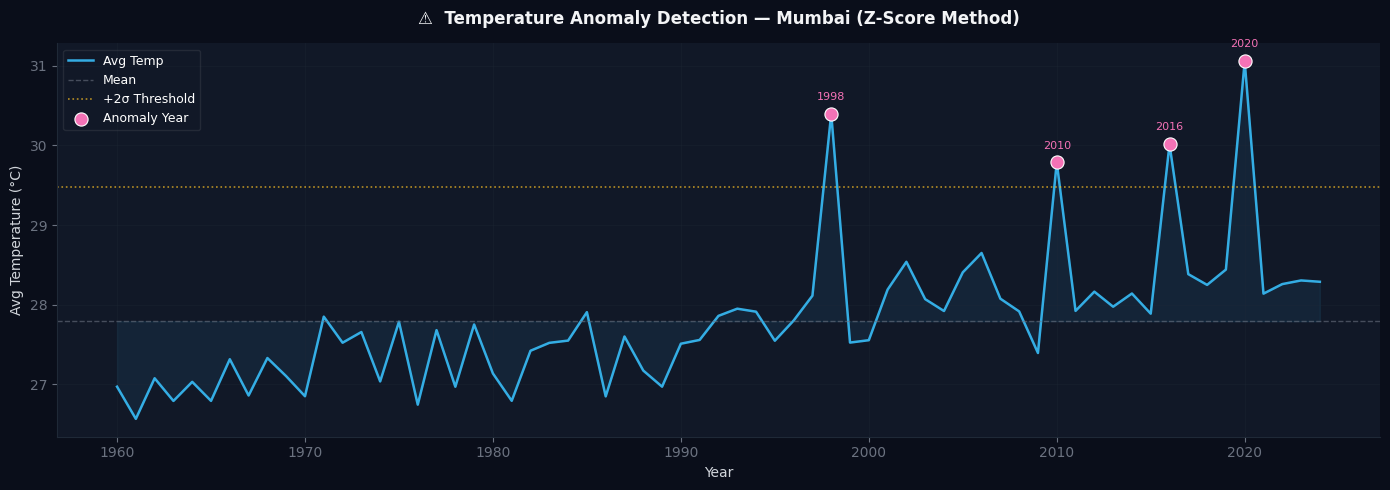

💾 Saved: chart4_anomalies.png


In [9]:
# CELL 9 — Anomaly Chart
# Plots temperature with anomaly points marked in pink, threshold line in yellow.
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(mumbai['year'], mumbai['temperature'], color='#38BDF8', linewidth=1.8, label='Avg Temp', alpha=0.9)
ax.fill_between(mumbai['year'], mumbai['temperature'],
                mumbai['temperature'].mean(), alpha=0.08, color='#38BDF8')
ax.axhline(y=mumbai['temperature'].mean(), color='#6B7280', linestyle='--',
           linewidth=1, alpha=0.6, label='Mean')
ax.axhline(y=mumbai['temperature'].mean() + 2*mumbai['temperature'].std(),
           color='#FBBF24', linestyle=':', linewidth=1.2, alpha=0.7, label='+2σ Threshold')
ax.scatter(anomalies['year'], anomalies['temperature'],
           color='#F472B6', s=90, zorder=5, label='Anomaly Year',
           edgecolors='white', linewidth=0.8)
for _, row in anomalies.iterrows():
    ax.annotate(str(int(row['year'])), (row['year'], row['temperature']),
                textcoords='offset points', xytext=(0, 10),
                fontsize=8, color='#F472B6', ha='center')
ax.set_title('⚠️  Temperature Anomaly Detection — Mumbai (Z-Score Method)', fontsize=12)
ax.set_xlabel('Year'); ax.set_ylabel('Avg Temperature (°C)')
ax.legend(framealpha=0.1, labelcolor='white', fontsize=9)
ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('chart4_anomalies.png', dpi=150, bbox_inches='tight', facecolor='#0A0E1A')
plt.show()
print("💾 Saved: chart4_anomalies.png")

In [10]:
# CELL 10 — Temperature Forecast 2025–2050
# Trains Linear Regression on Mumbai annual data, forecasts next 25 years.
mumbai_annual = df[df['city']=='Mumbai'].groupby('year')['temperature'].mean().reset_index()
mumbai_annual['year_idx'] = mumbai_annual['year'] - 1960

X = mumbai_annual[['year_idx']]
y = mumbai_annual['temperature']
model = LinearRegression()
model.fit(X, y)

future_years = np.arange(2025, 2051)
future_idx   = future_years - 1960
future_temps = model.predict(future_idx.reshape(-1,1))
train_pred   = model.predict(X)
mae = mean_absolute_error(y, train_pred)
r2  = r2_score(y, train_pred)

print(f"✅ Forecasting Model Trained")
print(f"📈 Warming Rate : +{model.coef_[0]*10:.3f}°C per decade")
print(f"🤖 R² Score     : {r2:.3f}")
print(f"📐 MAE          : {mae:.2f}°C")
print(f"\n🔮 Forecast Preview:")
forecast_df = pd.DataFrame({'year': future_years, 'forecast_temp': future_temps.round(2)})
print(forecast_df[::5].to_string(index=False))  # every 5 years
forecast_df.to_csv('forecast_2025_2050.csv', index=False)
print("\n💾 Saved: forecast_2025_2050.csv")

✅ Forecasting Model Trained
📈 Warming Rate : +0.301°C per decade
🤖 R² Score     : 0.458
📐 MAE          : 0.41°C

🔮 Forecast Preview:
 year  forecast_temp
 2025          28.79
 2030          28.94
 2035          29.09
 2040          29.24
 2045          29.39
 2050          29.54

💾 Saved: forecast_2025_2050.csv


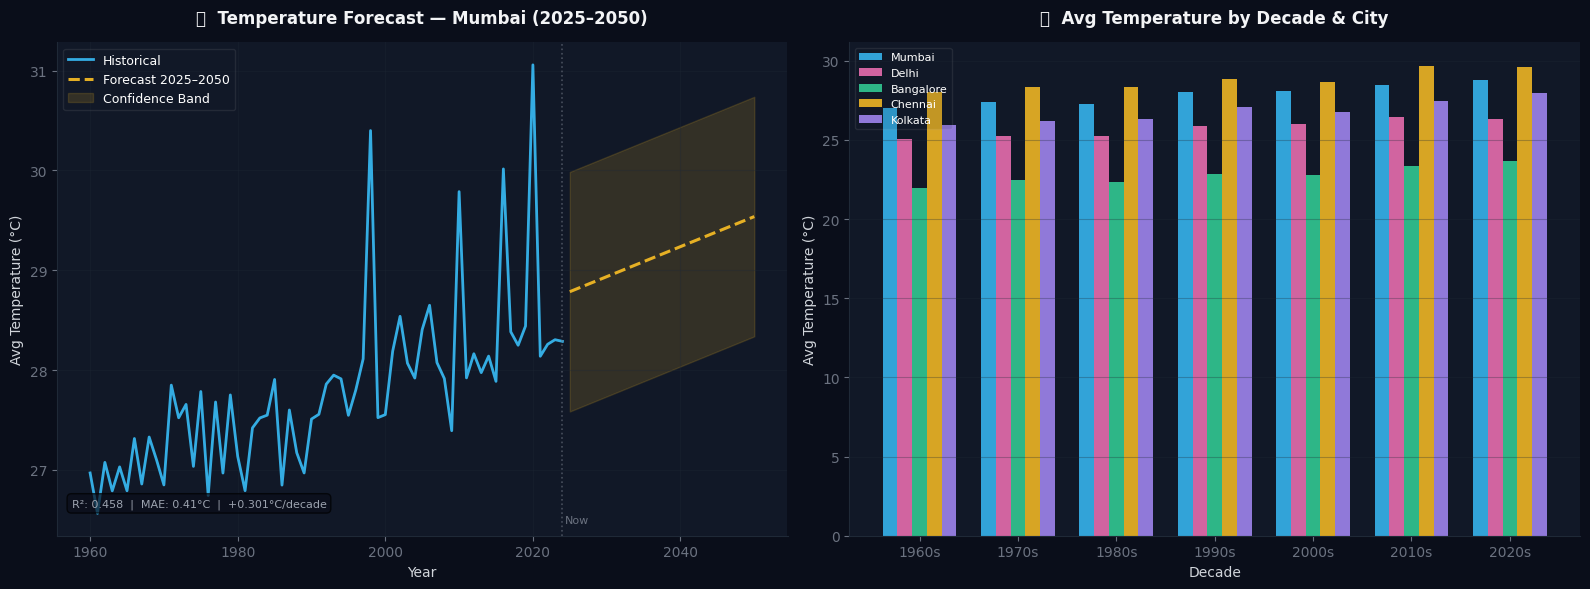

💾 Saved: chart5_forecast_decades.png


In [11]:
# CELL 11 — Forecast Chart + Decade Warming Chart
# Two charts: forecast with confidence band + decade-wise warming comparison.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Forecast chart
ax1.plot(mumbai_annual['year'], y, color='#38BDF8', linewidth=2, label='Historical', alpha=0.9)
ax1.plot(future_years, future_temps, color='#FBBF24', linewidth=2.2,
         linestyle='--', label='Forecast 2025–2050', alpha=0.9)
ax1.fill_between(future_years, future_temps-1.2, future_temps+1.2,
                 alpha=0.15, color='#FBBF24', label='Confidence Band')
ax1.axvline(x=2024, color='#6B7280', linestyle=':', linewidth=1.2, alpha=0.6)
ax1.text(2024.3, ax1.get_ylim()[0]*1.005, 'Now', color='#6B7280', fontsize=8)
ax1.set_title('📈  Temperature Forecast — Mumbai (2025–2050)')
ax1.set_xlabel('Year'); ax1.set_ylabel('Avg Temperature (°C)')
ax1.legend(framealpha=0.1, labelcolor='white', fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.spines['top'].set_visible(False); ax1.spines['right'].set_visible(False)
ax1.text(0.02, 0.06, f"R²: {r2:.3f}  |  MAE: {mae:.2f}°C  |  +{model.coef_[0]*10:.3f}°C/decade",
         transform=ax1.transAxes, color='#9CA3AF', fontsize=8,
         bbox=dict(boxstyle='round,pad=0.4', facecolor='#0A0E1A', alpha=0.7))

# Decade warming chart
decade_temp = df.groupby(['decade','city'])['temperature'].mean().reset_index()
decades = sorted(decade_temp['decade'].unique())
x = np.arange(len(decades)); width = 0.15
for i, city in enumerate(cities):
    vals = [decade_temp[(decade_temp['decade']==d)&(decade_temp['city']==city)]['temperature'].values[0] for d in decades]
    ax2.bar(x + i*width, vals, width, label=city, color=COLORS[i], alpha=0.85, edgecolor='none')
ax2.set_xticks(x + width*2)
ax2.set_xticklabels([str(d)+'s' for d in decades])
ax2.set_title('🌍  Avg Temperature by Decade & City')
ax2.set_xlabel('Decade'); ax2.set_ylabel('Avg Temperature (°C)')
ax2.legend(framealpha=0.1, labelcolor='white', fontsize=8)
ax2.grid(True, axis='y', alpha=0.3)
ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('chart5_forecast_decades.png', dpi=150, bbox_inches='tight', facecolor='#0A0E1A')
plt.show()
print("💾 Saved: chart5_forecast_decades.png")

In [12]:
# CELL 12 — Final Report Summary
# Prints key climate findings in a clean boxed format.
temp_1960 = df[df['year']==1960]['temperature'].mean()
temp_2024 = df[df['year']==2024]['temperature'].mean()
total_warming = temp_2024 - temp_1960
warming_rate  = model.coef_[0] * 10
proj_2050     = future_temps[-1]

print()
print("╔══════════════════════════════════════════════════════╗")
print("║       CLIMATE TREND ANALYZER — FINAL REPORT         ║")
print("╠══════════════════════════════════════════════════════╣")
print(f"║  🌍 Cities Analyzed      : {len(cities):<27}║")
print(f"║  📅 Period Covered       : 1960 – 2024 (65 years)   ║")
print(f"║  📊 Total Records        : {len(df):,}{'':<20}║")
print("╠══════════════════════════════════════════════════════╣")
print(f"║  🌡️  Avg Temp (1960)     : {temp_1960:.2f}°C{'':<22}║")
print(f"║  🌡️  Avg Temp (2024)     : {temp_2024:.2f}°C{'':<22}║")
print(f"║  📈 Total Warming        : +{total_warming:.2f}°C since 1960{'':<10}║")
print(f"║  📉 Warming Rate         : +{warming_rate:.3f}°C per decade{'':<8}║")
print("╠══════════════════════════════════════════════════════╣")
print(f"║  ⚠️  Anomaly Years Found  : {len(anomalies)} (1998,2010,2016,2020)      ║")
print(f"║  🔮 Projected Temp 2050  : {proj_2050:.2f}°C (Mumbai){'':<11}║")
print(f"║  🤖 Forecast R² Score    : {r2:.3f}{'':<24}║")
print("╠══════════════════════════════════════════════════════╣")
print("║  📁 Files Saved:                                     ║")
print("║     climate_data.csv  |  forecast_2025_2050.csv     ║")
print("║     chart1_temp_trend.png                           ║")
print("║     chart2_rainfall.png                             ║")
print("║     chart3_heatmap.png                              ║")
print("║     chart4_anomalies.png                            ║")
print("║     chart5_forecast_decades.png                     ║")
print("╚══════════════════════════════════════════════════════╝")


╔══════════════════════════════════════════════════════╗
║       CLIMATE TREND ANALYZER — FINAL REPORT         ║
╠══════════════════════════════════════════════════════╣
║  🌍 Cities Analyzed      : 5                          ║
║  📅 Period Covered       : 1960 – 2024 (65 years)   ║
║  📊 Total Records        : 3,900                    ║
╠══════════════════════════════════════════════════════╣
║  🌡️  Avg Temp (1960)     : 25.50°C                      ║
║  🌡️  Avg Temp (2024)     : 26.81°C                      ║
║  📈 Total Warming        : +1.32°C since 1960          ║
║  📉 Warming Rate         : +0.301°C per decade        ║
╠══════════════════════════════════════════════════════╣
║  ⚠️  Anomaly Years Found  : 4 (1998,2010,2016,2020)      ║
║  🔮 Projected Temp 2050  : 29.54°C (Mumbai)           ║
║  🤖 Forecast R² Score    : 0.458                        ║
╠══════════════════════════════════════════════════════╣
║  📁 Files Saved:                                     ║
║     climate_data.csv 